In [1]:
import pandas as pd
import plotly.graph_objects as go
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SELECTED="cyanine_selected_predictions.csv"
LIBRARY="cyanine_library_predictions.csv"

plt.rcParams["figure.dpi"] = 600
sns.set_style("whitegrid")

df_sel = pd.read_csv(SELECTED)
df_lib = pd.read_csv(LIBRARY)

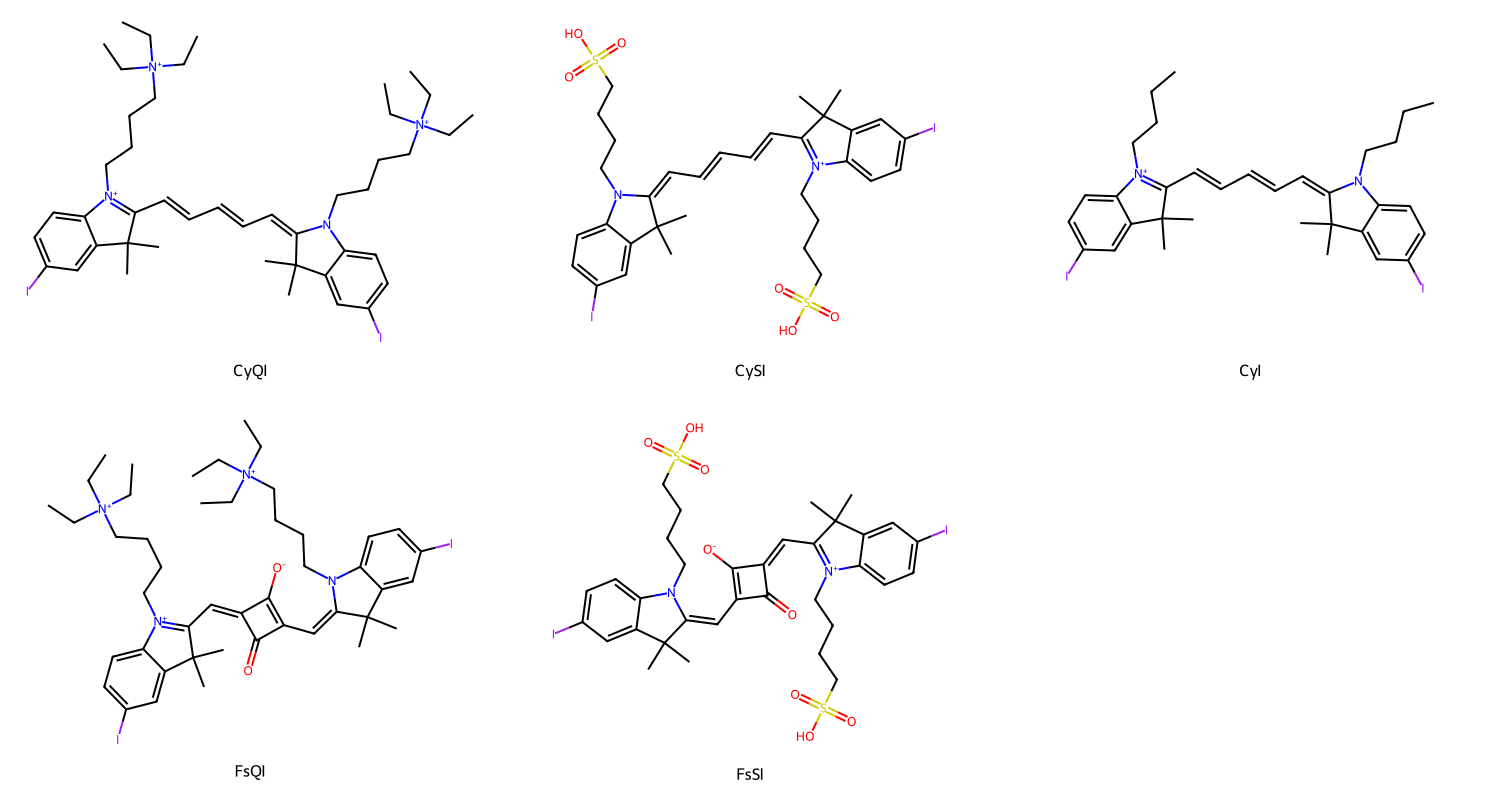

In [2]:
df_sel["mol"] = df_sel["smiles"].apply(Chem.MolFromSmiles)

mols = [Chem.MolFromSmiles(s) for s in df_sel["smiles"]]
labels = df_sel["name"].tolist() if "name" in df_sel.columns else None

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(500,400),
    legends=labels,
    returnPNG=False 
)

img

In [3]:
vmin = -9
vmax = -5

camera = dict(
    center=dict(x=0.06, y=0.0, z=0.0),
    eye=dict(x=1.63, y=0.20, z=1.26),
    up=dict(x=-0.38, y=-0.01, z=0.5)
)

fig = go.FigureWidget()
# library
fig.add_trace(go.Scatter3d(
    x=df_lib["log10_pampa"],
    y=df_lib["log10_caco2"],
    z=df_lib["log10_mdck"],
    mode="markers",
    customdata=df_lib["smiles"],
    marker=dict(
        size=2,
        color=df_lib["mean_value"],  
        colorscale="Jet",
        cmin=-7,
        cmax=-5.3,
        opacity=0.08,
        showscale=False  
    ),
    name="Library",
    hovertemplate="SMILES: %{customdata}<extra></extra>"
))

# selected
fig.add_trace(go.Scatter3d(
    x=df_sel["log10_pampa"],
    y=df_sel["log10_caco2"],
    z=df_sel["log10_mdck"],
    mode="markers",
    marker=dict(
        size=6,
        color=df_sel["mean_value"],
        colorscale="Jet",
        cmin=-7,
        cmax=-5.3,
        opacity=0.95,
        line=dict(width=1, color="black"),
        colorbar=dict(
            title="Mean value",
            x=1.08,
            len=0.7
        )
    ),
    name="Selected",
    hovertext=df_sel["name"],
    hovertemplate="Name: %{hovertext}<extra></extra>"
))

# text
z_offset = 0.05
fig.add_trace(go.Scatter3d(
    x=df_sel["log10_pampa"],
    y=df_sel["log10_caco2"],
    z=df_sel["log10_mdck"] + z_offset,
    mode="text",
    text=df_sel["name"],
    textposition="top center",
    textfont=dict(
        size=16,
        color="black"
    ),
    showlegend=False,
    hoverinfo="skip"
))

fig.update_layout(
    font=dict(family="Arial", 
              size=16,
              color="black"), 
              

    legend=dict(
        orientation="h",
        y=1.05,
        x=0.5,
        xanchor="center"
    ),

    margin=dict(t=80),

    scene=dict(
        xaxis=dict(
            range=[vmin, vmax],
            nticks=5,
            tickformat=".1f",
            title=dict(text="log10 PAMPA", font=dict(size=18)),
            tickfont=dict(size=14,
                          color="black")
        ),
        yaxis=dict(
            range=[vmin, vmax],
            nticks=5,
            tickformat=".1f",
            title=dict(text="log10 Caco2", font=dict(size=18)),
            tickfont=dict(size=14,
                          )
        ),
        zaxis=dict(
            range=[vmin, vmax],
            nticks=5,
            tickformat=".1f",
            title=dict(text="log10 MDCK", font=dict(size=18)),
            tickfont=dict(size=14,
                          color="black")
        ),
    ),

    scene_camera=camera,
    scene_aspectmode="manual",
    scene_aspectratio=dict(x=1, y=1.5, z=0.8),

    width=1000,
    height=650
)

display(fig)


FigureWidget({
    'data': [{'customdata': array(['CCN1/C(=C\\C2=C([O-])/C(=C/c3[se]c4ccccc4[n+]3CC)C2=O)C(C)(C)c2ccccc21',
                                   'CCN1/C(=C\\C2=C([O-])/C(=C/c3[se]c4ccccc4[n+]3CC)C2=O)C(C)(C)c2cc(Br)ccc21',
                                   'CCN1/C(=C\\C2=C([O-])/C(=C/c3[se]c4ccccc4[n+]3CC)C2=O)C(C)(C)c2cc(I)ccc21',
                                   ...,
                                   'CC1(C)C(/C=C2\\C(=O)C(/C=C3/N(Cc4ccsc4)c4ccccc4C3(C)C)=C2O)=[N+](Cc2ccsc2)c2ccc(I)cc21',
                                   'CC1(C)C(/C=C2\\C(=O)C(/C=C3/N(Cc4ccsc4)c4ccc(Br)cc4C3(C)C)=C2O)=[N+](Cc2ccsc2)c2ccc(I)cc21',
                                   'CC1(C)C(/C=C2\\C(=O)C(/C=C3/N(Cc4ccsc4)c4ccc(I)cc4C3(C)C)=C2O)=[N+](Cc2ccsc2)c2ccc(I)cc21'],
                                  dtype=object),
              'hovertemplate': 'SMILES: %{customdata}<extra></extra>',
              'marker': {'cmax': -5.3,
                         'cmin': -7,
                         'color'

In [ ]:
fig.write_image("permeability_3D.svg")
fig.write_html("permeability_3D.html")